In [1]:
# importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/tourism_data.csv')

In [3]:
df.head()

,Visitor ID,District,Month Number,Month,Year,Domestic Visitors,Foreign Visitors,Total Visitors
0,visitor-10,Adilabad,9,September,2014,491279,8,491287
1,visitor-100,Karimnagar,3,March,2014,1018399,0,1018399
2,visitor-1000,Kumaram Bheem Asifabad,3,March,2017,2767,0,2767
3,visitor-1001,Kumaram Bheem Asifabad,4,April,2017,3074,0,3074
4,visitor-1002,Kumaram Bheem Asifabad,5,May,2017,3416,0,3416


In [4]:
df.shape

(3456, 8)

In [5]:
df.dtypes

,0
Visitor ID,object
District,object
Month Number,int64
Month,object
Year,int64
Domestic Visitors,int64
Foreign Visitors,int64
Total Visitors,int64


In [6]:
df.describe()

,Month Number,Year,Domestic Visitors,Foreign Visitors,Total Visitors
count,3456.000000,3456.000000,3.456000e+03,3456.000000,3.456000e+03
mean,6.500000,2018.677083,2.133307e+05,446.662616,2.137774e+05
std,3.452552,2.793606,8.273808e+05,2998.880202,8.280667e+05
min,1.000000,2014.000000,0.000000e+00,0.000000,0.000000e+00
25%,3.750000,2016.000000,5.595000e+02,0.000000,6.007500e+02
50%,6.500000,2019.000000,2.215200e+04,0.000000,2.215200e+04
75%,9.250000,2021.000000,1.800025e+05,0.000000,1.800062e+05
max,12.000000,2023.000000,2.070378e+07,38933.000000,2.070417e+07


In [7]:
df.isnull().sum()

,0
Visitor ID,0
District,0
Month Number,0
Month,0
Year,0
Domestic Visitors,0
Foreign Visitors,0
Total Visitors,0


In [8]:
#Step 2: Combine into a datetime
df['Date'] = pd.to_datetime(df['Month'] + ' ' + df['Year'].astype(str), format='%B %Y')

In [9]:
df.head()

,Visitor ID,District,Month Number,Month,Year,Domestic Visitors,Foreign Visitors,Total Visitors,Date
0,visitor-10,Adilabad,9,September,2014,491279,8,491287,2014-09-01
1,visitor-100,Karimnagar,3,March,2014,1018399,0,1018399,2014-03-01
2,visitor-1000,Kumaram Bheem Asifabad,3,March,2017,2767,0,2767,2017-03-01
3,visitor-1001,Kumaram Bheem Asifabad,4,April,2017,3074,0,3074,2017-04-01
4,visitor-1002,Kumaram Bheem Asifabad,5,May,2017,3416,0,3416,2017-05-01


In [10]:
df.tail()

,Visitor ID,District,Month Number,Month,Year,Domestic Visitors,Foreign Visitors,Total Visitors,Date
3451,visitor-995,Khammam,10,October,2017,155943,0,155943,2017-10-01
3452,visitor-996,Khammam,11,November,2017,110800,0,110800,2017-11-01
3453,visitor-997,Khammam,12,December,2017,137825,0,137825,2017-12-01
3454,visitor-998,Kumaram Bheem Asifabad,1,January,2017,2241,0,2241,2017-01-01
3455,visitor-999,Kumaram Bheem Asifabad,2,February,2017,2490,0,2490,2017-02-01


In [11]:
# Step 3: Sort by date
df = df.sort_values(by='Date')

In [12]:
df.head()

,Visitor ID,District,Month Number,Month,Year,Domestic Visitors,Foreign Visitors,Total Visitors,Date
1445,visitor-230,Nizamabad,1,January,2014,576,3,579,2014-01-01
2768,visitor-38,Jagtial,1,January,2014,0,0,0,2014-01-01
1777,visitor-26,Hyderabad,1,January,2014,1122510,0,1122510,2014-01-01
2644,visitor-338,Warangal,1,January,2014,0,469,469,2014-01-01
2902,visitor-50,Jangaon,1,January,2014,0,0,0,2014-01-01


### Vistualization to get some insights on data

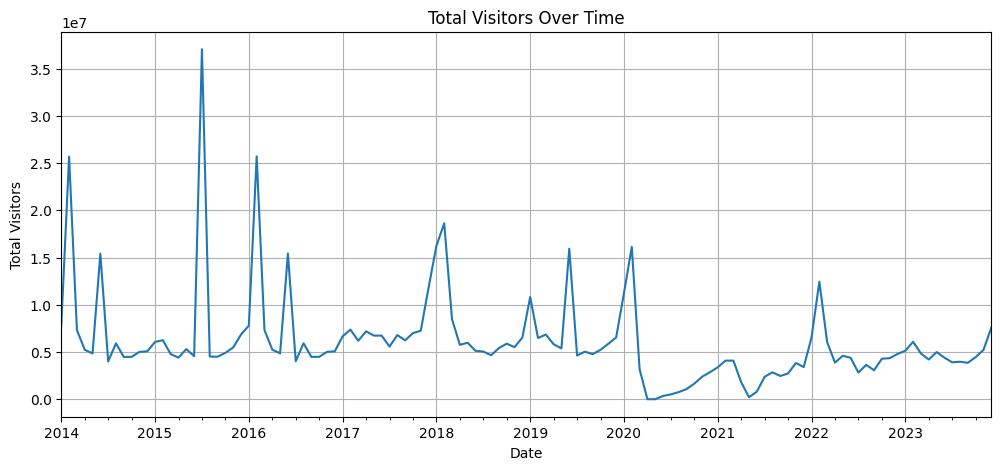

In [13]:
# --- Total Visitors Over Time ----
df_grouped = df.groupby('Date')['Total Visitors'].sum()

plt.figure(figsize=(12, 5))
df_grouped.plot()
plt.title("Total Visitors Over Time")
plt.xlabel("Date")
plt.ylabel("Total Visitors")
plt.grid()
plt.show()

Conclusion:

So we can see the total number of visitors over years we can see increasing and decreasing trend over years.

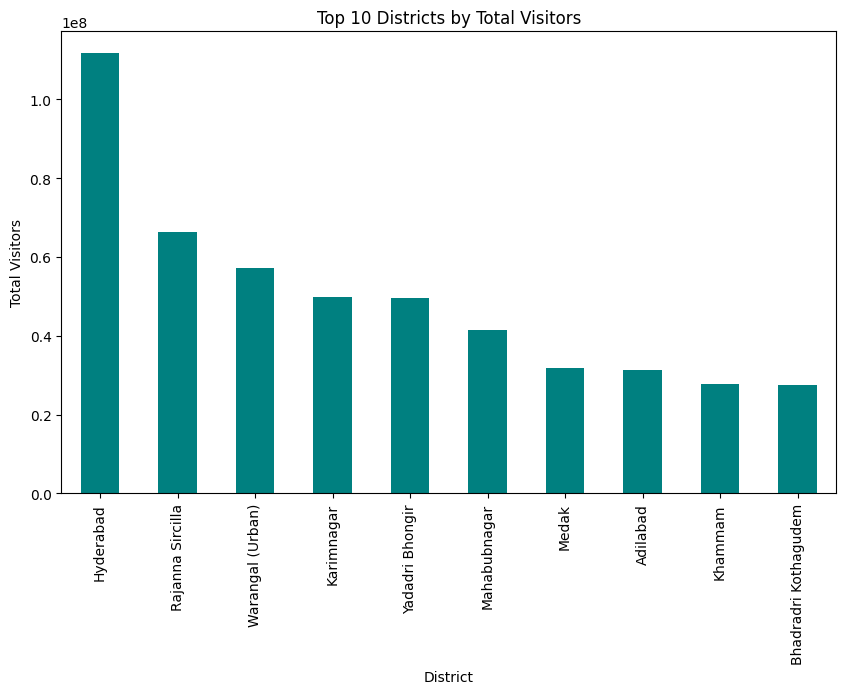

In [14]:
# ---- Top 10 Districts by Total Visitors ----
top_districts = df.groupby('District')['Total Visitors'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top_districts.plot(kind='bar', color='teal')
plt.title("Top 10 Districts by Total Visitors")
plt.ylabel("Total Visitors")
plt.xticks(rotation=90)
plt.show()

Conclusion:

We can see the top 10 visitors by district ie. which district has most visitiors. Like hyderabad got most then Rajanna Sircilla and so on.

/tmp/ipython-input-15-4021106054.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly_pattern.index, y=monthly_pattern.values, palette='viridis')


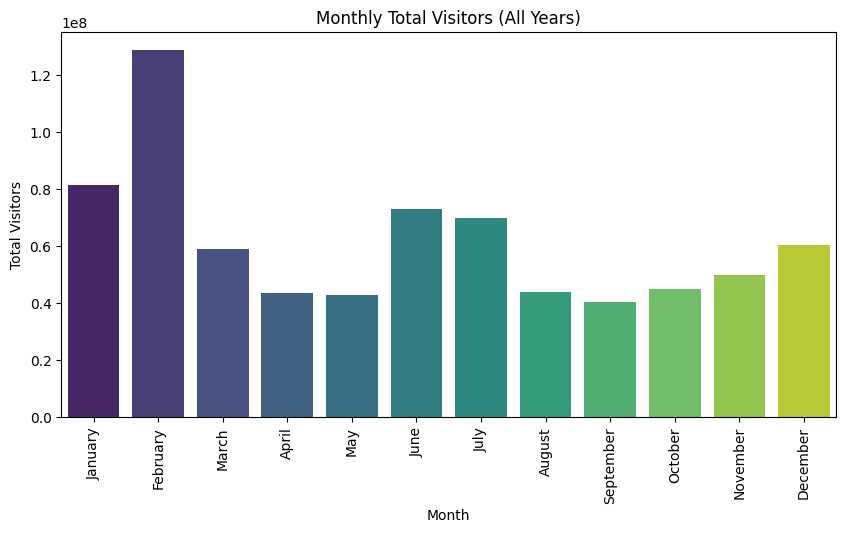

In [15]:
# ----- Monthly Seasonality Pattern (All Years Combined) ----
monthly_pattern = df.groupby('Month')['Total Visitors'].sum().reindex(
    ['January','February','March','April','May','June','July','August','September','October','November','December'])

plt.figure(figsize=(10, 5))
sns.barplot(x=monthly_pattern.index, y=monthly_pattern.values, palette='viridis')
plt.title("Monthly Total Visitors (All Years)")
plt.xticks(rotation=90)
plt.ylabel("Total Visitors")
plt.show()

Conclusion:

We can se seasonality trent from given plot Month of january , February , june , july , december show more number of visitors.

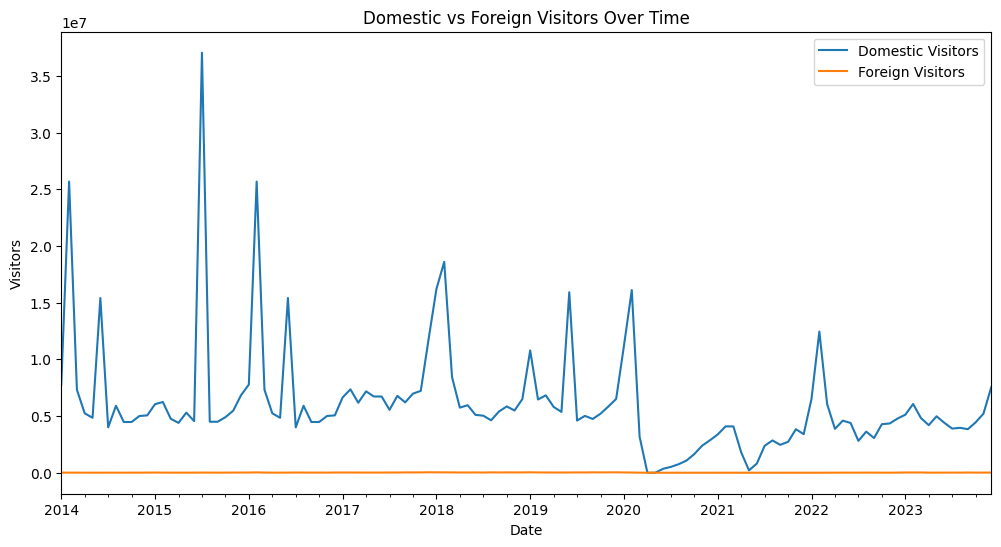

In [16]:
# ----- Domestic vs Foreign Visitors Over Time ----
df_domestic = df.groupby('Date')['Domestic Visitors'].sum()
df_foreign = df.groupby('Date')['Foreign Visitors'].sum()

plt.figure(figsize=(12, 6))
df_domestic.plot(label='Domestic Visitors')
df_foreign.plot(label='Foreign Visitors')
plt.legend()
plt.title("Domestic vs Foreign Visitors Over Time")
plt.ylabel("Visitors")
plt.show()

Conclusion:

Most of the visitors are domestic rather then foreign over years.

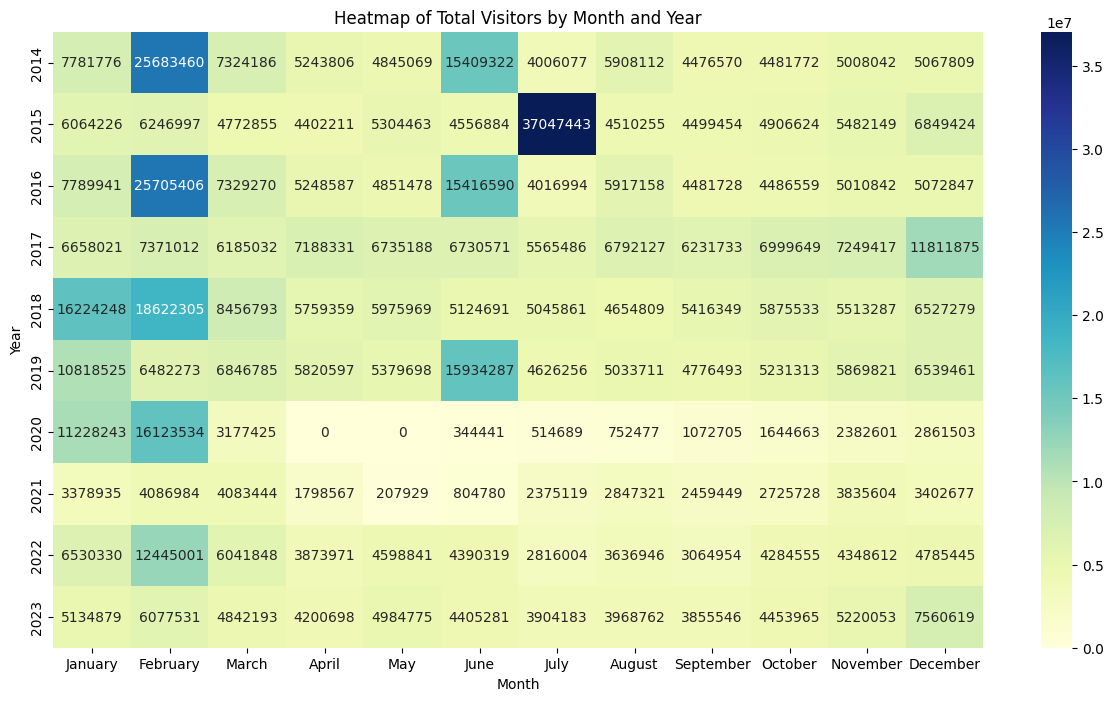

In [17]:
# ---- Heatmap of Total Visitors by Year and Month ---
pivot = df.pivot_table(values='Total Visitors', index='Year', columns='Month', aggfunc='sum')
# Order months correctly
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
pivot = pivot[month_order]

plt.figure(figsize=(15, 8))
sns.heatmap(pivot, cmap='YlGnBu', annot=True, fmt=".0f")
plt.title("Heatmap of Total Visitors by Month and Year")
plt.show()


Conclusion:

The given heatmap shows the number of visitors over years for each month.

In [18]:
# Sum total visitors per district
total_visitors_by_district = df.groupby('District')['Total Visitors'].sum()

# Sort districts by total visitors descending
total_visitors_sorted = total_visitors_by_district.sort_values(ascending=False)

print(total_visitors_sorted.head(10))  # Top 10 districts by visitors

District
Hyderabad               111638408
Rajanna Sircilla         66217204
Warangal (Urban)         57172514
Karimnagar               49768586
Yadadri Bhongir          49536650
Mahabubnagar             41460058
Medak                    31768820
Adilabad                 31281419
Khammam                  27868469
Bhadradri Kothagudem     27418241
Name: Total Visitors, dtype: int64


### Forecast Total Visitors for a specific district (or a few top ones) using ARIMA

In [19]:
district_name = 'Hyderabad'
df_district = df[df['District'] == district_name].copy()
df_district.set_index('Date', inplace=True)
df_district = df_district.asfreq('MS')  # Ensure it's monthly start frequency

ADF Statistic: 0.7890443341575196
p-value: 0.9914572489639805


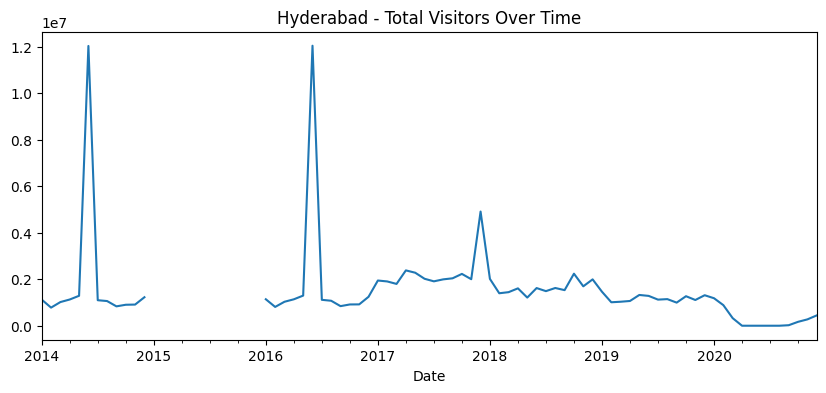

In [20]:
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

# Plot raw data
df_district['Total Visitors'].plot(title=f"{district_name} - Total Visitors Over Time", figsize=(10,4))

# ADF Test (Augmented Dickey-Fuller)
result = adfuller(df_district['Total Visitors'].dropna())
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')

# If p > 0.05 → non-stationary → apply differencing

<Axes: title={'center': 'Differenced Series'}, xlabel='Date'>

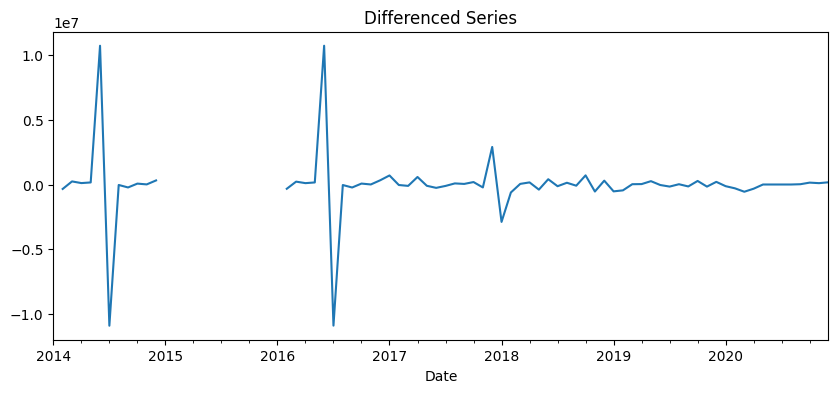

In [21]:
# apply differing
df_district['diff'] = df_district['Total Visitors'].diff()

df_district['diff'].plot(title="Differenced Series", figsize=(10,4))

                               SARIMAX Results                                
Dep. Variable:         Total Visitors   No. Observations:                   84
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -1130.599
Date:                Fri, 20 Jun 2025   AIC                           2267.197
Time:                        13:21:00   BIC                           2274.454
Sample:                    01-01-2014   HQIC                          2270.113
                         - 12-01-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0119      0.224      0.053      0.958      -0.426       0.450
ma.L1         -0.9335      0.090    -10.397      0.000      -1.109      -0.757
sigma2      4.927e+12   3.68e-14   1.34e+26      0.0

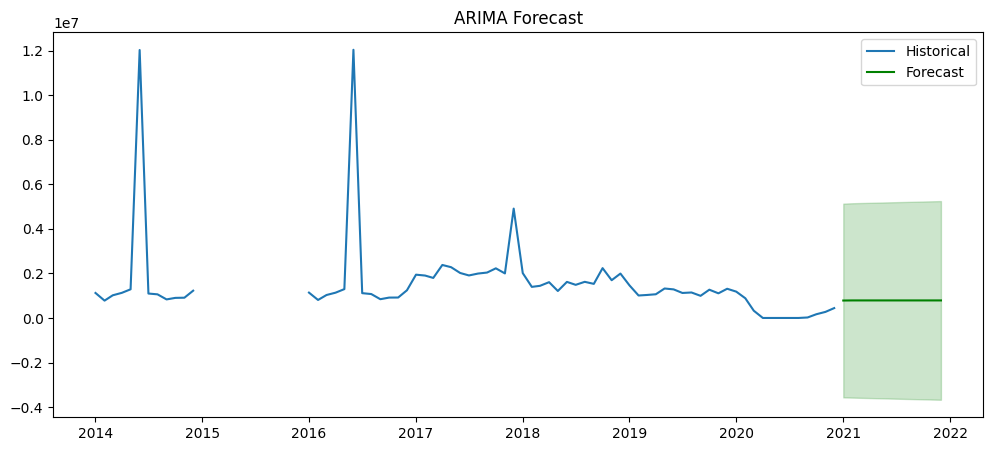

In [26]:
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# Choose order (p,d,q)
# For starters, you can try (1,1,1) or (2,1,2)
order = (1, 1, 1)

# Fit ARIMA model
model = ARIMA(df_district['Total Visitors'], order=order)
model_fit = model.fit()

# Summary
print(model_fit.summary())

# Forecast next 12 months
forecast_steps = 12
forecast_result = model_fit.get_forecast(steps=forecast_steps)
forecast = forecast_result.predicted_mean
conf_int = forecast_result.conf_int()

# Plot historical + forecast
plt.figure(figsize=(12, 5))
plt.plot(df_district['Total Visitors'], label='Historical')
plt.plot(forecast.index, forecast, label='Forecast', color='green')
plt.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='green', alpha=0.2)
plt.title("ARIMA Forecast")
plt.legend()
plt.show()


### Seasonal Pattern Discovery by district

In [27]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

district_name = 'Hyderabad'
df_district = df[df['District'] == district_name].copy()

# Set Date as index
df_district.set_index('Date', inplace=True)

# Make sure data is monthly frequency
df_district = df_district.asfreq('MS')


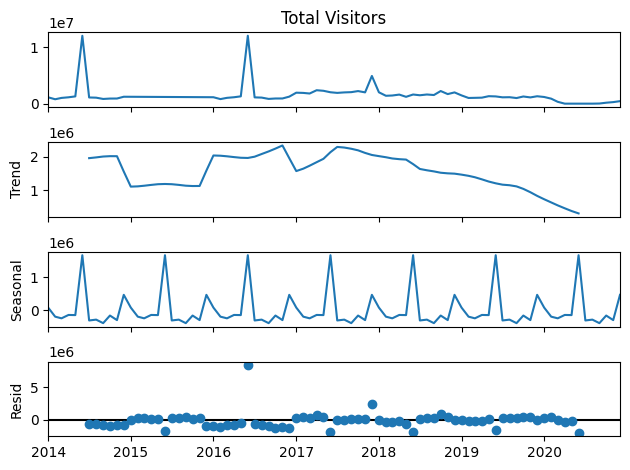

In [29]:
# Fill missing values using interpolation
df_district['Total Visitors'] = df_district['Total Visitors'].interpolate(method='time')

# Now seasonal_decompose should work
result = seasonal_decompose(df_district['Total Visitors'], model='additive')  # or model='multiplicative'

# You can then plot the results
result.plot()
plt.show()